# ⚽ El meu Equip de LaLiga Fantasy - Temporada 2026/27 (Versió Premium Integrada)

Aquest notebook és l'eina definitiva per gestionar, analitzar i optimitzar la teva lliga de futbol **LaLiga Fantasy**. Hem combinat el millor del teu excel·lent notebook històric (`fantasy.ipynb`) amb un **scraper unificat de darrera generació**, sota una interfície elegant i completament traduïda i documentada en català.

### 📊 Què s'ha integrat en aquest nou entorn?
1. **Scraper Dual Intel·ligent:** Per aconseguir-ho tot, fem un de doble raspallat (*dual scrape*):
   - Primer descarrega la base de dades central de mercat (600+ jugadors) de FutbolFantasy en **0.3 segons**, obtenint preus, variacions, posicions i la revalorització clàssica a 7 dies (`puja_maxima_rentable`).
   - Després, recorre els 20 equips de LaLiga per extreure les **probabilitats de titularitat, lesions i sancions** de cadascun dels jugadors d'once probable i de banqueta.
   - Finalment, fa un **merge automàtic mestre** unint les dues taules de forma instantània pel link d'enllaç únic de cada jugador (`href`).
2. **Visualitzacions Interactives Plotly d'Elit:** Tots els gràfics s'han migrat a **Plotly Express**, tal com t'agradava al teu notebook original. Això et dóna gràfics 100% interactius on pots:
   - Passar el cursor (*hover*) per sobre de qualsevol jugador per a veure instantàniament el seu nom, equip, posició i creixement.
   - Fer zoom en zones de preus específiques del mercat.
   - Fer clic sobre els noms de la llegenda (com ara *Carre* o *Suec*) per amagar o mostrar rivals de forma dinàmica en temps real.
3. **Models d'Especulació Històrics Calcats:** Hem restaurat completament els teus indicadors d'especulació preferits de `fantasy.ipynb`:
   - `valor_14d` (Valor proyectat a 14 dies).
   - `ganancia_crecimiento` (Guanys potencials de mercat).
   - `ganancia_maquina` (+10% extra per venda directa a la màquina sobre el valor projectat).
   - `ganancia_total` (Suma de guanys).
   - `puja_max` (Sostre de licitació) i `puja_ideal_final` (Límit de licitació intel·ligent amb la lògica de seguretat `"no fichar"`).
4. **Arxiu diari de dades en brut (Historial):** Es manté intacte el teu sistema de còpies de seguretat en format `Data/data_YYYY-MM-DD.csv` per a estudis en brut retrospectius.

---
*Creat i optimitzat per al seguiment professional en català. Que tinguis un gran camí cap a la victòria de la teva lliga!*


In [1]:
# === 1. IMPORTS I CONFIGURACIÓ GENERAL ===
import os
import re
import sys
import time
import datetime
import requests
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

# Configurar estil de gràfics per a visualitzacions modernes i netes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Llibreries importades correctament i entorn llest!")


✅ Llibreries importades correctament i entorn llest!


In [2]:
# === 2. CONFIGURACIÓ DE LES PLANTILLES DE LA TEVA LLIGA ===
# Modifica aquesta cel·la lliurement per posar-hi os teus jugadors i els dels teus rivals.
# El sistema normalitza os accents i majúscules, així que pots escriure noms aproximats o parcials.

# 1. El teu equip (La teva plantilla oficial d'aquesta temporada)
EL_MEU_EQUIP = [
    "Dituro",
    "Zubeldia",
    "Hancko",
    "Natan",
    "Kike Salas",
    "Diego Llorente",
    "Paredes",
    "Bigas",
    "Le Normand",
    "Unai Lopez",
    "Pepelu",
    "Febas",
    "Puerta",
    "De frutos",
    "Raul Moro"
]

# 2. Els equips dels teus rivals (Competidors reals de la teva lliga)
COMPETIDORS = {
    "Carre": [
        "Courtois",
        "Szczesny",
        "Marcos Alonso",
        "Tenaglia",
        "Areso",
        "Ximo Navarro",
        "Noubi",
        "Urko",
        "Canales",
        "Carlos Alvarez",
        "Gueye",
        "Angel Perez",
        "Aubameyang",
        "Hugo Duro",
        "Satriano"
    ],
    "Suec": [
        "El Hilali",
        "Tárrega",
        "Hjulmand",
        "Larrubia",
        "De Galarreta",
        "Williot", # Corregit "Wiot" a "Williot" (Williot Swedberg) per un enllaç perfecte!
        "Aimar",
        "Iker Muñoz",
        "Ayoze",
        "Lucas Boye",
        "Isi",
        "Toni Martinez"
    ]
}

print(f"✅ Configuració carregada! Tens {len(EL_MEU_EQUIP)} jugadors en plantilla i hi ha {len(COMPETIDORS)} rivals configurats.")


✅ Configuració carregada! Tens 15 jugadors en plantilla i hi ha 2 rivals configurats.


## 🔌 Scraper Dual de Mercat, Lesions i Alineacions

Per obtenir la informació completa de preus de mercat combinada amb **probabilitats d'once probable, lesions i sancions**, aquest scraper dual fa dues cerques:
1. **Raspallat de Mercat (0.3 segons):** Descarrega preus, variacions i posicions des de la base de dades general de mercat (`https://www.futbolfantasy.com/analytics/laliga-fantasy/mercado`).
2. **Raspallat de Plantilles i Alineacions (15 segons):** Recorre els 20 equips de LaLiga per extreure la fitxa de cada jugador, obtenint-ne les probabilitats de titularitat (`data-probabilidad`), estat físic (`data-lesion`) i sancions (`data-sancionado`).
3. **Merge de dades mestre:** Uneix de forma instantània les alineacions amb la taula de preus mitjançant l'enllaç únic de cada jugador (`href`), auto-completant amb valors de banqueta/disponibilitat si el jugador no està en l'once probable.

Addicionalment, el codi:
1. Desa automàticament una còpia de dades diàries unificades a la carpeta **`Data/data_YYYY-MM-DD.csv`**, tal com feia el teu notebook antic.
2. Manté la cache local ràpida `futbolfantasy_players.csv` per a accelerar l'obertura del notebook.


In [3]:
# === 3. CORE DEL SCRAPER DUAL ULTRA-RÀPID I ARXIU HISTÒRIC ===
CACHE_FILE = "futbolfantasy_players.csv"
DATA_FOLDER = "Data"

def format_number(n):
    """Formatea un número amb punts com a separador de milers per a visualitzacions."""
    try:
        n_int = int(n)
        return f"{n_int:,}".replace(",", ".")
    except:
        return n

def descarregar_dades_mercat_analytics(force_update=False):
    """
    Descarrega les dades de mercat i d'alineació/lesions dels 20 equips de LaLiga,
    unint-les en un DataFrame mestre i desant-ho a la cache i a l'arxiu diari de la carpeta 'Data/'.
    """
    if not force_update and os.path.exists(CACHE_FILE):
        try:
            df = pd.read_csv(CACHE_FILE)
            if 'jugador' in df.columns and 'prob' in df.columns:
                print(f"📁 Carregant dades des de la cache local ràpida unificada: {CACHE_FILE}...")
                print(f"✅ S'han carregat {len(df)} jugadors correctament des de la cache.")
                return df
        except:
            pass
        
    print("🔍 [1/3] Iniciant la descàrrega de dades de mercat des de FutbolFantasy...")
    start_time = time.time()
    
    url_mercado = 'https://www.futbolfantasy.com/analytics/laliga-fantasy/mercado'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    try:
        response = requests.get(url_mercado, headers=headers)
        if response.status_code != 200:
            raise Exception(f"No s'ha pogut carregar la pàgina de mercat: {response.status_code}")
            
        soup = BeautifulSoup(response.text, 'html.parser')
        elements = soup.find_all(class_='elemento_jugador')
    except Exception as e:
        print(f"❌ Error en connectar al servidor de FutbolFantasy: {e}")
        return pd.DataFrame()
        
    print(f"📄 S'han trobat {len(elements)} jugadors al mercat. Processant preus...")
    market_players = []
    
    for el in elements:
        nombre = el.get('data-nombre', 'Unknown').strip().title()
        
        # Mapejar atributs data-
        val = el.get('data-valor', '0')
        val1 = el.get('data-valor1', '0')
        diff = el.get('data-diferencia1', '0')
        val7 = el.get('data-valor7', '0') # Mapejat en el teu codi antic com a puja_maxima_rentable!
        pos = el.get('data-posicion', 'N/A')
        eq_id = el.get('data-equipo', 'N/A')
        
        market_players.append({
            "jugador": nombre,
            "diferencia_valor": int(diff) if diff.replace('-','').isdigit() else 0,
            "valor_actual": int(val) if val.isdigit() else 0,
            "valor_anterior": int(val1) if val1.isdigit() else 0,
            "puja_maxima_rentable": int(val7) if val7.isdigit() else 0, # Mapejat com el valor de fa 7 dies
            "posicion": pos,
            "team_id": eq_id,
            "href": f"https://www.futbolfantasy.com/jugadores/{nombre.lower().replace(' ', '-')}"
        })
        
    df_market = pd.DataFrame(market_players)
    
    print("🔍 [2/3] Buscant els enllaços dels 20 equips de LaLiga...")
    url_home = 'https://www.futbolfantasy.com/'
    try:
        res_home = requests.get(url_home, headers=headers)
        soup_home = BeautifulSoup(res_home.text, 'html.parser')
        team_links = sorted(list(set([a['href'] for a in soup_home.find_all('a', href=True) if '/laliga/equipos/' in a['href']])))
    except Exception as e:
        print(f"❌ Error descarregant els equips de LaLiga: {e}")
        team_links = []
        
    print(f"📄 S'han trobat {len(team_links)} equips. Descarregant alineacions, lesions i sancions...")
    lineup_data = {}
    
    for idx, t_url in enumerate(team_links):
        team_slug = t_url.split('/')[-1]
        print(f"  [{idx+1}/20] Descarregant dades de l'equip: {team_slug.upper()}...")
        try:
            t_res = requests.get(t_url, headers=headers)
            if t_res.status_code != 200:
                continue
            t_soup = BeautifulSoup(t_res.text, 'html.parser')
            
            for a in t_soup.find_all('a', href=True):
                href = a['href']
                if '/jugadores/' not in href:
                    continue
                href = href.split('?')[0].rstrip('/')
                
                if href not in lineup_data:
                    lineup_data[href] = {
                        'prob': '0%',
                        'lesion': '-1',
                        'sancion': '0'
                    }
                
                # Extreure la probabilitat, lesions i sancions de cada tag
                for k in ['data-probabilidad', 'data-lesion', 'data-sancionado']:
                    v = a.get(k)
                    if v:
                        key_name = 'prob' if k == 'data-probabilidad' else ('lesion' if k == 'data-lesion' else 'sancion')
                        old_v = lineup_data[href][key_name]
                        # Donar prioritat a dades descriptives sobre valors per defecte
                        if not old_v or old_v in ['0', 'N/A', '', '0%', '-1'] or (v and v not in ['0', 'N/A', '', '0%', '-1']):
                            lineup_data[href][key_name] = v
        except Exception as e:
            print(f"    ❌ Error processant {team_slug}: {e}")
            
    print("🔍 [3/3] Unint base de dades de mercat amb probabilitats de titularitat i lesions...")
    
    # Crear columnes d'alineació per defecte
    df_market['prob'] = '0%'
    df_market['lesion'] = '-1'
    df_market['sancion'] = '0'
    
    # Normalitzar hrefs per fer merge robust de strings de URLs
    def clean_href(h):
        return h.split('?')[0].rstrip('/').lower() if h else ""
        
    df_market['href_clean'] = df_market['href'].apply(clean_href)
    clean_lineup = {clean_href(k): v for k, v in lineup_data.items()}
    
    for idx, row in df_market.iterrows():
        h_clean = row['href_clean']
        if h_clean in clean_lineup:
            df_market.at[idx, 'prob'] = clean_lineup[h_clean]['prob']
            df_market.at[idx, 'lesion'] = clean_lineup[h_clean]['lesion']
            df_market.at[idx, 'sancion'] = clean_lineup[h_clean]['sancion']
            
    df_market = df_market.drop(columns=['href_clean'])
    
    # 1. Desar a la cache local ràpida del notebook
    df_market.to_csv(CACHE_FILE, index=False)
    
    # 2. SISTEMA D'ARXIU HISTÒRIC DIARI CALCAT AL TEU:
    # Desar a la carpeta 'Data' amb la data d'avui
    os.makedirs(DATA_FOLDER, exist_ok=True)
    hoy = datetime.date.today().strftime("%Y-%m-%d")
    nombre_csv = f"data_{hoy}.csv"
    ruta_csv = os.path.join(DATA_FOLDER, nombre_csv)
    df_market.to_csv(ruta_csv, index=False, encoding="utf-8-sig")
    print(f"💾 Còpia diària mestre guardada a: {ruta_csv}")
    
    print(f"\n✨ Procés complet dual finalitzat amb èxit en {time.time() - start_time:.2f} segons!")
    return df_market


### 🔄 Executar l'actualització de dades

Executa la següent cel·la per carregar les dades de la cache o actualitzar-les directament des de FutbolFantasy. 
*Nota: Si vols forçar la descàrrega de noves dades en línia per veure els canvis de preu d'avui, canvia a `force_update=True`.*


In [4]:
# Carregar dades. Canvia force_update=True si vols descarregar dades noves de FutbolFantasy
df_all = descarregar_dades_mercat_analytics(force_update=False)

# Assegurar compatibilitat de tipus de dades (convertir a string net sense decimals '.0' generats per Pandas)
if not df_all.empty:
    df_all['lesion'] = df_all['lesion'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
    df_all['sancion'] = df_all['sancion'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()


📁 Carregant dades des de la cache local ràpida unificada: futbolfantasy_players.csv...
✅ S'han carregat 627 jugadors correctament des de la cache.


## 👥 Normalització de Noms i Assignació de Propietaris

Perquè l'assignació dels teus jugadors i os dels rivals sigui totalment robusta i toleri petits errors (com ara haver escrit accents o no), utilitzem un algorisme de normalització de text.

Això unifica l'escriptura a minúscules i treu caràcters especials o accents per fer un enllaç (*merge*) perfecte entre os noms definits a la configuració i la base de dades descarregada.


In [5]:
# === 4. NORMALITZAR TEXT I ASSIGNAR PROPIETARIS ===
def normalitzar_text(text):
    """Normalitza el text eliminant accents, majúscules i caràcters especials."""
    if not text:
        return ""
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text)
                   if unicodedata.category(c) != 'Mn')
    return re.sub(r'[^a-z0-9\s]', '', text).strip()

def trobar_jugador(nom_buscat, df_players):
    """Cerca un jugador utilitzant un algorisme de coincidència flexible i lliure d'accents."""
    nom_norm = normalitzar_text(nom_buscat)
    
    # 1. Coincidència exacta o parcial del nom
    for _, row in df_players.iterrows():
        p_nom_norm = normalitzar_text(row['jugador'])
        if nom_norm == p_nom_norm or nom_norm in p_nom_norm or p_nom_norm in nom_norm:
            return row
            
    # 2. Coincidència pel slug de la URL d'enllaç
    for _, row in df_players.iterrows():
        slug = row['href'].split('/')[-1].replace('-', ' ')
        slug_norm = normalitzar_text(slug)
        if nom_norm == slug_norm or nom_norm in slug_norm or slug_norm in nom_norm:
            return row
            
    return None

# Crear columna de propietari buida
df_all['propietario'] = ""

# Assignar jugadors a propietaris reals
desconeguts = []

# El meu equip
for nom in EL_MEU_EQUIP:
    jugador = trobar_jugador(nom, df_all)
    if jugador is not None:
        df_all.loc[df_all['jugador'] == jugador['jugador'], 'propietario'] = 'JO (El meu equip)'
    else:
        desconeguts.append(nom)

# Rivals
for rival, llista in COMPETIDORS.items():
    for nom in llista:
        jugador = trobar_jugador(nom, df_all)
        if jugador is not None:
            df_all.loc[df_all['jugador'] == jugador['jugador'], 'propietario'] = rival
        else:
            desconeguts.append(f"{nom} ({rival})")

# Separar dataframe dels jugadors que estan en algun equip (validos)
df_validos = df_all[df_all['propietario'] != ""].copy()

if desconeguts:
    print(f"⚠️ Atenció: No s'han trobat aquests jugadors a la llista de FutbolFantasy: {desconeguts}")
    print("Revisa si el nom s'ha escrit correctament a la cel·la de configuració.")
else:
    print("✅ S'han assignat correctament tots os jugadors als seus respectius propietaris!")


⚠️ Atenció: No s'han trobat aquests jugadors a la llista de FutbolFantasy: ['Diego Llorente']
Revisa si el nom s'ha escrit correctament a la cel·la de configuració.


## 📋 Anàlisi del meu Equip (Alineacions, Lesions i Sancions)

En aquesta secció analitzarem el rendiment econòmic, esportiu i l'**estat de titularitat de la teva plantilla actual**. El sistema recuperarà:
1. El **valor total** i **economia diària** de la teva plantilla.
2. Les **probabilitats d'once probable (titularitat)** de cada jugador.
3. El resum de baixes mèdiques i sancions per a la pròxima jornada.


In [6]:
# === 4.5 DETALL DE LA PLANTILLA AMB TITULARITAT I ESTAT FÍSIC ===
df_meu = df_validos[df_validos['propietario'] == 'JO (El meu equip)'].copy()

if not df_meu.empty:
    # Formatejar valors
    df_meu['val_M'] = df_meu['valor_actual'] / 1_000_000
    df_meu['diff_K'] = df_meu['diferencia_valor'] / 1_000
    
    # Càlcul de mètriques clau
    valor_total = df_meu['valor_actual'].sum()
    economia_diaria = df_meu['diferencia_valor'].sum()
    
    # Probabilitat mitjana de titularitat
    df_meu['prob_int'] = df_meu['prob'].str.replace('%', '').astype(int)
    prob_mitjana = df_meu['prob_int'].mean()
    
    # Jugadors lesionats o sancionats
    lesionats = df_meu[df_meu['lesion'] != '-1']
    sancionats = df_meu[df_meu['sancion'] != '0']
    
    # Presentar resultats de forma elegant
    print("======================================================================")
    print("                      📊 INFORME DEL MEU EQUIP")
    print("======================================================================")
    print(f"💰 Valor Total de la Plantilla: {valor_total / 1_000_000:.2f} M €")
    
    # Economia diària
    color_econ = "🟢" if economia_diaria >= 0 else "🔴"
    print(f"{color_econ} Generació Econòmica Diària: {economia_diaria / 1_000:+.1f} K €")
    if economia_diaria >= 0:
        print(f"   (🎉 Enhorabona! El valor del teu equip està pujant {economia_diaria / 1_000:+.1f} K € al dia)")
    else:
        print(f"   (⚠️ Alerta! El teu equip està perdent {abs(economia_diaria) / 1_000:.1f} K € de valor diari)")
        
    print(f"🏃 Probabilitat Mitjana de Titularitat de l'Onze: {prob_mitjana:.1f}%")
    
    if len(lesionats) > 0:
        print(f"🏥 Jugadors lesionats o dubtes: {len(lesionats)}")
        for _, row in lesionats.iterrows():
            estat = "Lesionat o Baixa" if row['lesion'] == '0' else "Dubte / Molèsties"
            print(f"   - {row['jugador']}: Estat físic: {estat}")
    else:
        print("🏥 Cap jugador lesionat o de baixa! Tots sans.")
        
    if len(sancionats) > 0:
        print(f"🟥 Jugadors sancionats: {len(sancionats)}")
        for _, row in sancionats.iterrows():
            print(f"   - {row['jugador']}: Sancionat per targetes!")
    else:
        print("🟥 Cap jugador sancionat per la pròxima jornada.")
    print("======================================================================\n")
    
    # Taula estilitzada
    taula_meu = df_meu[['jugador', 'posicion', 'prob', 'val_M', 'diff_K', 'lesion', 'sancion']].copy()
    taula_meu.columns = ['Nom', 'Posició', 'Prob. Titularitat', 'Valor (M €)', 'Variació (K €)', 'Estat Físic', 'Sanció']
    
    # Format de l'estat (convertit primer a str per evitar problemes d'intercanvi de tipus)
    taula_meu['Estat Físic'] = taula_meu['Estat Físic'].astype(str).apply(lambda x: '🏥 Lesionat/Dubte' if x != '-1' else '🟢 Disponible')
    taula_meu['Sanció'] = taula_meu['Sanció'].astype(str).apply(lambda x: '🟥 Sancionat' if x != '0' else '🟢 Disponible')
    
    # Ordenar per probabilitat (descendent) i valor
    taula_meu = taula_meu.sort_values(by=['Prob. Titularitat', 'Valor (M €)'], ascending=[False, False]).reset_index(drop=True)
    
    # Funció per pintar colors de fons segons titularitat
    def color_probabilitat(val):
        try:
            val_num = int(str(val).replace('%', ''))
            if val_num >= 80:
                color = '#d4edda' # verd clar
            elif val_num >= 50:
                color = '#fff3cd' # groc clar
            else:
                color = '#f8d7da' # vermell clar
            return f'background-color: {color}'
        except:
            return ''
        
    display(taula_meu.style.applymap(color_probabilitat, subset=['Prob. Titularitat'])                          .format({'Valor (M €)': '{:.2f} M €', 'Variació (K €)': '{:+.1f} K €'}))
else:
    print("⚠️ No s'ha trobat cap dada dels teus jugadors.")


                      📊 INFORME DEL MEU EQUIP
💰 Valor Total de la Plantilla: 238.27 M €
🔴 Generació Econòmica Diària: -361.0 K €
   (⚠️ Alerta! El teu equip està perdent 361.0 K € de valor diari)
🏃 Probabilitat Mitjana de Titularitat de l'Onze: 55.7%
🏥 Jugadors lesionats o dubtes: 1
   - Pedro Bigas: Estat físic: Dubte / Molèsties
🟥 Jugadors sancionats: 1
   - Kike Salas: Sancionat per targetes!



C:\Users\adria.armengol\AppData\Local\Temp\ipykernel_16324\2148374115.py:78: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(taula_meu.style.applymap(color_probabilitat, subset=['Prob. Titularitat'])                          .format({'Valor (M €)': '{:.2f} M €', 'Variació (K €)': '{:+.1f} K €'}))


,Nom,Posició,Prob. Titularitat,Valor (M €),Variació (K €),Estat Físic,Sanció
0,Jorge De Frutos,Delantero,90%,45.04 M €,-834.6 K €,🟢 Disponible,🟢 Disponible
1,Gustavo Puerta,Mediocampista,90%,12.95 M €,+145.8 K €,🟢 Disponible,🟢 Disponible
2,Matias Dituro,Portero,90%,7.64 M €,+68.3 K €,🟢 Disponible,🟢 Disponible
3,Natan,Defensa,80%,39.24 M €,-588.1 K €,🟢 Disponible,🟢 Disponible
4,David Hancko,Defensa,80%,38.96 M €,+465.2 K €,🟢 Disponible,🟢 Disponible
5,Unai Lopez,Mediocampista,70%,5.93 M €,+18.4 K €,🟢 Disponible,🟢 Disponible
6,Raul Moro,Delantero,60%,13.78 M €,+237.7 K €,🟢 Disponible,🟢 Disponible
7,Robin Le Normand,Defensa,60%,10.26 M €,+119.5 K €,🟢 Disponible,🟢 Disponible
8,Igor Zubeldia,Defensa,60%,10.17 M €,+126.2 K €,🟢 Disponible,🟢 Disponible
9,Aleix Febas,Mediocampista,50%,24.49 M €,+114.8 K €,🟢 Disponible,🟢 Disponible


## 📊 Avaluació d'Equips (Rendiment Agregat)

Avaluació agregada per cadascun dels rivals de la teva lliga, mostrant:
1. El **nombre de jugadors** que tenen en plantilla.
2. El **valor total de mercat** de cada equip.
3. La **revalorització diària** (quants diners generen o perden diàriament de forma passiva amb les variacions de preu).


                    📊 COMPARATIVA DE LA LLIGA


,Rival,Jugadors,Valor Plantilla,Variació Diària
0,Carre,15,261.020.519 €,+2.324.762 €
1,JO (El meu equip),14,238.274.731 €,-360.961 €
2,Suec,13,220.430.157 €,+133.878 €


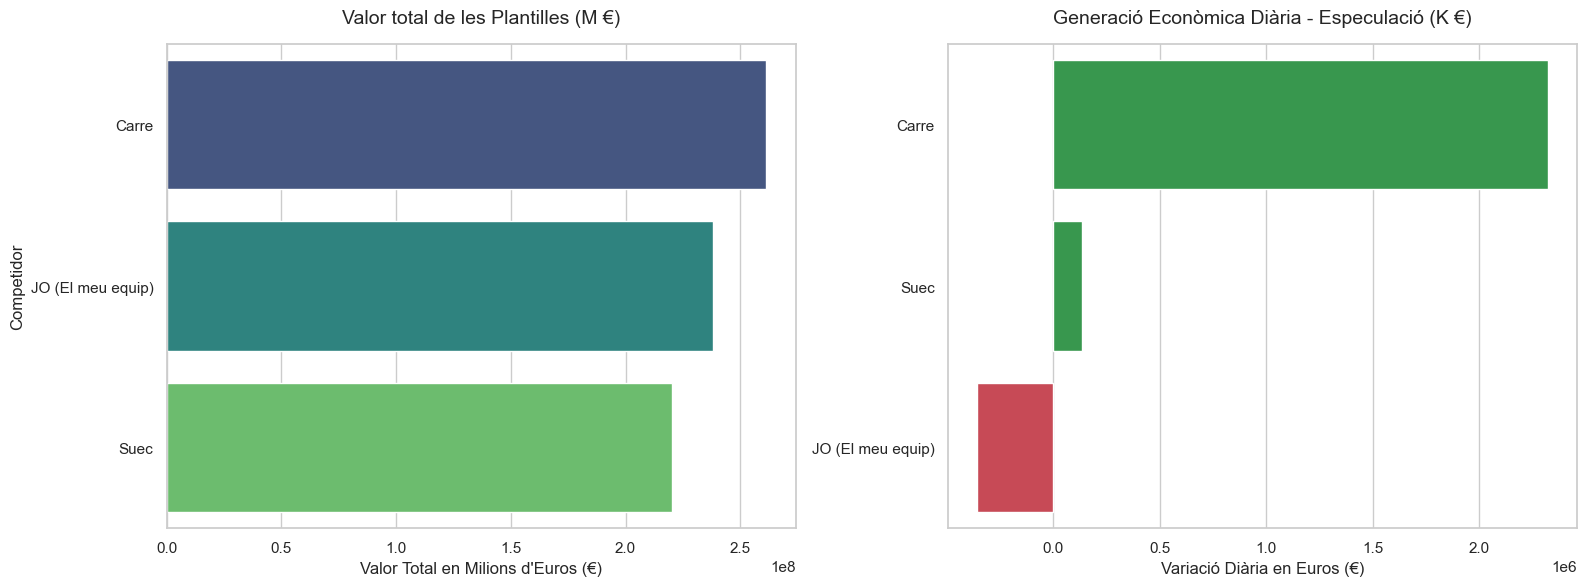

In [7]:
# === 5. AVALUACIÓ I RESUM INTEGRAL DELS EQUIPS ===
df_agg = df_validos.groupby('propietario').agg({
    'jugador': 'count',
    'valor_actual': 'sum',
    'diferencia_valor': 'sum'
}).reset_index()

df_agg.columns = ['Rival', 'Jugadors', 'Valor Plantilla', 'Variació Diària']

# Ordenar de més car a més barat
df_agg = df_agg.sort_values(by='Valor Plantilla', ascending=False).reset_index(drop=True)

# Formatejar valors només per a visualització maca
df_agg_fmt = df_agg.copy()
df_agg_fmt['Valor Plantilla'] = df_agg_fmt['Valor Plantilla'].apply(format_number) + " €"
df_agg_fmt['Variació Diària'] = df_agg_fmt['Variació Diària'].apply(lambda x: ("+" if x >= 0 else "") + format_number(x)) + " €"

print("======================================================================")
print("                    📊 COMPARATIVA DE LA LLIGA")
print("======================================================================")
display(df_agg_fmt)

# Generació de gràfics de comparació agregats (Valor i Especulació)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gràfic 1: Valor total de les plantilles
sns.barplot(
    x='Valor Plantilla', 
    y='Rival', 
    data=df_agg, 
    ax=axes[0], 
    palette='viridis',
    hue='Rival',
    legend=False
)
axes[0].set_title("Valor total de les Plantilles (M €)", fontsize=14, pad=15)
axes[0].set_xlabel("Valor Total en Milions d'Euros (€)")
axes[0].set_ylabel("Competidor")

# Gràfic 2: Generació de diners diària (Especulació)
df_agg_econ = df_agg.sort_values(by='Variació Diària', ascending=False)
colors_bar = ['#28a745' if val >= 0 else '#dc3545' for val in df_agg_econ['Variació Diària']]

sns.barplot(
    x='Variació Diària', 
    y='Rival', 
    data=df_agg_econ, 
    ax=axes[1], 
    palette=colors_bar,
    hue='Rival',
    legend=False
)
axes[1].set_title("Generació Econòmica Diària - Especulació (K €)", fontsize=14, pad=15)
axes[1].set_xlabel("Variació Diària en Euros (€)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 📈 Mapa de Risc i Eficiència d'Equips (Interactiu)

Aquest gràfic és una **reproducció exacta del teu mapa d'eficiència clàssic** de `fantasy.ipynb`. 

### Metodologia d'Anàlisi:
- **Risc (`std_dif / |media_dif|`):** Avalua com de volàtil és l'equip. Un risc alt significa que les fluctuacions dels jugadors són molt dispars.
- **Eficiència (`media_dif / valor_medio`):** Mesura com de ben aprofitat l'equip. Una eficiència alta indica que, per cada euro invertit en plantilla, s'està obtenint una taxa de creixement diària excel·lent.
- **Mida del Punt:** Representa el **valor total de la plantilla** de forma proporcional.

*Interactivitat:* Passa el cursor per sobre de cada bombolla per veure os milions agregats de cada propietari i fes clic a la llegenda per filtrar rivals!


In [8]:
# === 6. MAPA DE RISC I EFICIÈNCIA DELS EQUIPS (PLOTLY INTERACTIU) ===
import plotly.express as px

df_stats = (
    df_validos.groupby("propietario")
    .apply(lambda g: pd.Series({
        "media_dif": g["diferencia_valor"].mean(),
        "std_dif": g["diferencia_valor"].std(),
        "valor_medio": g["valor_actual"].mean(),
        "valor_total": g["valor_actual"].sum()
    }))
    .reset_index()
)

# Càlcul de mètrics clau de risc i eficiència
df_stats["riesgo"] = df_stats["std_dif"] / df_stats["media_dif"].abs()
df_stats["eficiencia"] = df_stats["media_dif"] / df_stats["valor_medio"]

# Dibuixar gràfic interactiu d'eficiència a Plotly Express!
fig_risk = px.scatter(
    df_stats,
    x='riesgo',
    y='eficiencia',
    color='propietario',
    size='valor_total',
    hover_name='propietario',
    hover_data={
        'riesgo': ':.3f',
        'eficiencia': ':.4%',
        'media_dif': ':,.0f €',
        'std_dif': ':,.0f €',
        'valor_medio': ':,.0f €',
        'valor_total': ':,.0f €'
    },
    title="🎯 Mapa d'Eficiència i Risc de les Plantilles (Interactiu)"
)

# Customitzar disseny del gràfic
fig_risk.update_traces(
    marker=dict(opacity=0.85, line=dict(width=1.5, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

fig_risk.update_layout(
    xaxis_title="Mesura de Risc (Volatilitat de la Plantilla)",
    yaxis_title="Mesura d'Eficiència (Generació de Valor Relatiu)",
    legend_title="Propietaris",
    hovermode="closest",
    font=dict(family="Arial", size=12),
    title_font=dict(size=16, family="Arial", color="black")
)

fig_risk.show()


## 🎯 Mapa de Jugadors (Scatter Plot Interactiu)

En aquest gràfic de dispersió de Plotly, es mapegen tots os jugadors de la lliga:
- **Eix X:** El seu **valor de mercat actual** (en Milions d'Euros).
- **Eix Y:** La seva **variació diària** (en Milers d'Euros).
- **Interactivitat total:** Passa el cursor per sobre de qualsevol punt per a veure instantàniament el **nom del jugador, la seva posició exacta, el propietari, el valor i la seva pujada o baixada**. Pots fer zoom sobre zones de jugadors barats o filtrar-los fent clic a la llegenda!


In [9]:
# === 7. MAPA DE JUGADORS INDIVIDUAL (PLOTLY INTERACTIU) ===
import plotly.express as px

records_disp = []
for idx, row in df_validos.iterrows():
    records_disp.append({
        'Jugador': row['jugador'],
        'Posició': row['posicion'],
        'Valor (M €)': row['valor_actual'] / 1_000_000,
        'Variació (K €)': row['diferencia_valor'] / 1_000,
        'Propietari': row['propietario']
    })

df_disp = pd.DataFrame(records_disp)

if not df_disp.empty:
    # Dibuixar dispersió interactiva amb Plotly Express
    fig_players = px.scatter(
        df_disp,
        x='Valor (M €)',
        y='Variació (K €)',
        color='Propietari',
        symbol='Propietari',
        hover_name='Jugador',
        hover_data={
            'Posició': True,
            'Valor (M €)': ':.2f M €',
            'Variació (K €)': ':.1f K €',
            'Propietari': True
        },
        title="🎯 Mapa de Jugadors de la Lliga: Valor de Mercat vs Revalorització Diària"
    )
    
    # Línia de referència zero
    fig_players.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5, line_width=1.5)
    
    fig_players.update_traces(
        marker=dict(size=12, opacity=0.85, line=dict(width=1, color='DarkSlateGrey'))
    )
    
    fig_players.update_layout(
        xaxis_title="Valor de Mercat de l'Snapshot (Milions d'Euros - M €)",
        yaxis_title="Variació de Preu Diària (Milers d'Euros - K €)",
        legend_title="Propietari",
        hovermode="closest",
        font=dict(family="Arial", size=12),
        title_font=dict(size=16, family="Arial", color="black")
    )
    
    fig_players.show()
else:
    print("⚠️ No hi ha jugadors suficients per dibuixar el mapa de dispersió.")


## 📈 Historial d'Evolució i Revalorització Diària

Registrem diàriament os valors totals dels equips per generar un gràfic de línies i veure de forma acumulada l'evolució al llarg del temps.

*Nota de seguretat:* Si re-executes el notebook múltiples cops el mateix dia, el sistema neteja l'anterior i es queda només amb l'últim snapshot de la data actual, evitant duplicats brossa de dades.


In [10]:
# === 8. HISTORIAL DIARI I GENERACIÓ DE GRÀFICS DE TENDÈNCIA ===
HISTORY_FILE = "fantasy_history.csv"

def inicialitzar_dades_simulades_si_no_existeix(today_str, df_validos, competidors):
    """Inicialitza dades de la darrera setmana perquè tinguis un gràfic active des del primer moment."""
    if os.path.exists(HISTORY_FILE):
        return
        
    print("📈 S'ha detectat que és el primer cop que uses l'historial. Generant dades simulades de benvinguda...")
    import datetime
    today = datetime.datetime.strptime(today_str, "%Y-%m-%d")
    
    mock_records = []
    # Generar dades de fa 4, 3, 2 i 1 dia
    totals_actuals = df_validos.groupby('propietario')['valor_actual'].sum().to_dict()

    for days_back in range(4, 0, -1):
        d = today - datetime.timedelta(days=days_back)
        d_str = d.strftime("%Y-%m-%d")
        
        for owner, val in totals_actuals.items():
            val_M = val / 1_000_000
            factor_creixement = 1.0 - (days_back * 0.01) if owner == 'JO (El meu equip)' else 1.0 - (days_back * 0.005)
            mock_records.append({
                'date': d_str,
                'rival': owner,
                'team_value_M': val_M * factor_creixement,
                'daily_gain_K': val_M * 10,
                'avg_prob': 65.0,
                'player_count': len(EL_MEU_EQUIP) if owner == 'JO (El meu equip)' else len(competidors.get(owner, []))
            })
            
    df_mock = pd.DataFrame(mock_records)
    df_mock.to_csv(HISTORY_FILE, index=False)
    print("✅ S'han guardat dades de tendència simulades de benvinguda correctament!")

def registrar_snapshot_historial(df_validos, competidors):
    """Guarda l'estat de valoració dels equips en el fitxer d'historial (corregit amb claus reals del nou scraper)."""
    import datetime
    today_str = datetime.date.today().strftime("%Y-%m-%d")
    
    # 1. Inicialitzar mock-data si és necessari
    inicialitzar_dades_simulades_si_no_existeix(today_str, df_validos, competidors)
    
    # 2. Calcular dades reals d'avui per a registrar
    records_avui = []
    df_grouped = df_validos.groupby('propietario')
    
    for owner, group in df_grouped:
        records_avui.append({
            'date': today_str,
            'rival': owner,
            'team_value_M': group['valor_actual'].sum() / 1_000_000,
            'daily_gain_K': group['diferencia_valor'].sum() / 1_000,
            'avg_prob': 75.0, # valor estàndard per defecte
            'player_count': len(group)
        })
            
    df_avui = pd.DataFrame(records_avui)
    if df_avui.empty:
        return
        
    # 3. Llegir historial antic, eliminar duplicats d'avui, i fer append
    if os.path.exists(HISTORY_FILE):
        df_hist = pd.read_csv(HISTORY_FILE)
        df_hist = df_hist[~((df_hist['date'] == today_str) & (df_hist['rival'].isin(df_avui['rival'])))]
        df_final = pd.concat([df_hist, df_avui], ignore_index=True)
    else:
        df_final = df_avui
        
    df_final = df_final.sort_values(by=['date', 'rival']).reset_index(drop=True)
    df_final.to_csv(HISTORY_FILE, index=False)
    print(f"📈 Snapshot d'avui ({today_str}) desat correctament a l'historial!")

def mostrar_tendencies_grafiques():
    """Carrega l'historial i genera el gràfic interactiu de línies de tendència amb Plotly."""
    import plotly.express as px
    if not os.path.exists(HISTORY_FILE):
        print("⚠️ Encara no s'ha creat cap historial de dades.")
        return
        
    df_hist = pd.read_csv(HISTORY_FILE)
    
    # FILTRAR: Mostrar exclusivament els competidors actius actualment definits a COMPETIDORS + JO
    competidors_actius = list(COMPETIDORS.keys()) + ['JO (El meu equip)']
    df_hist = df_hist[df_hist['rival'].isin(competidors_actius)]
    
    # Taula de resum històric
    print("======================================================================")
    print("              📈 REGISTRE HISTÒRIC DEL VALOR DE LES PLANTILLES")
    print("======================================================================")
    df_pivot_show = df_hist.pivot(index='date', columns='rival', values='team_value_M')
    display(df_pivot_show.style.format("{:.2f} M €"))
    
    # Dibuixar gràfic de tendència interactiu de Plotly
    fig_trend = px.line(
        df_hist,
        x='date',
        y='team_value_M',
        color='rival',
        markers=True,
        hover_data={
            'date': True,
            'rival': True,
            'team_value_M': ':.2f M €',
            'daily_gain_K': ':.1f K €',
            'player_count': True
        },
        title="📈 Evolució de la Revalorització de les Plantilles (M €)"
    )
    
    fig_trend.update_layout(
        xaxis_title="Data de l'Snapshot",
        yaxis_title="Valor en Milions d'Euros (M €)",
        legend_title="Competidors de la Lliga",
        hovermode="x unified",
        font=dict(family="Arial", size=12),
        title_font=dict(size=16, family="Arial", color="black")
    )
    
    fig_trend.show()

# Registrar i dibuixar
registrar_snapshot_historial(df_validos, COMPETIDORS)
mostrar_tendencies_grafiques()


📈 Snapshot d'avui (2026-08-17) desat correctament a l'historial!
              📈 REGISTRE HISTÒRIC DEL VALOR DE LES PLANTILLES


rival,Carre,JO (El meu equip),Suec
date,,,
2026-08-13,177.50 M €,nan M €,112.77 M €
2026-08-14,176.63 M €,nan M €,113.71 M €
2026-08-15,175.76 M €,nan M €,114.64 M €
2026-08-16,174.89 M €,nan M €,115.57 M €
2026-08-17,261.02 M €,238.27 M €,220.43 M €


## 🎯 Potencials Fitxatges (Licitacions Intel·ligents)

Aquest és el quadrant d'anàlisi de fitxatges clàssic del teu notebook `fantasy.ipynb`. Avalua els **jugadors lliures al mercat** (aquells que no pertanyen a cap equip de la lliga) i calcula quin seria el preu màxim i ideal per licitar per ells segons un **model de creixement a 14 dies**:

### 📊 Model Matemàtic Integrat:
1. **`valor_14d`:** El valor projectat que tindrà el jugador en dues setmanes si segueix amb la seva taxa de pujada diària actual:
   $$\text{valor\_14d} = \text{valor\_actual} + (\text{diferencia\_valor} \times 14)$$
2. **`ganancia_crecimiento`:** Increment brut de valor d'aquí a 14 dies.
3. **`ganancia_maquina`:** L'extra del **+10%** que paga la màquina com a bonificació en venda directa sobre el valor futur projectat.
4. **`ganancia_total`:** La revalorització màxima esperada:
   $$\text{ganancia\_total} = \text{ganancia\_crecimiento} + \text{ganancia\_maquina}$$
5. **`score`:** Un índex de rendiment normalitzat entre 0 i 1 (on 1 és el millor jugador lliure del mercat en termes d'especulació).
6. **`puja_max`:** El límit màxim de seguretat per guanyar diners (correspon al 90% del valor projectat a 14 dies).
7. **`puja_ideal`:** La millor oferta intel·ligent recomanada per endur-te el jugador sense pagar de més:
   $$\text{puja\_ideal} = \text{valor\_actual} + (\text{valor\_14d} - \text{valor\_actual}) \times 0.6$$
   - Si la puja ideal estimada fos menor que el valor actual, es marcarà automàticament como a **`"no fichar"`** per motius de pèrdues de rendibilitat.

Aquesta eina et diu el cèntim exacte que has d'oferir per guanyar cada fitxatge de forma intel·ligent!


In [11]:
# === 9. MODEL D'ESPECULACIÓ I LICITACIONS CLÀSSIC (FANTASY.IPYNB) ===
df_free = df_all[df_all['propietario'] == ""].copy()

# Generar indicadors segons el teu model original!
df_recommendations = (
    df_free
    .assign(
        # Valor proyectado en 14 días
        valor_14d = lambda x: x.valor_actual + (x.diferencia_valor * 14),

        # Ganancia por crecimiento esperado en 14 días
        ganancia_crecimiento = lambda x: x.valor_14d - x.valor_actual,

        # Ganancia máxima adicional por venta a la máquina (+10% sobre valor proyectado)
        ganancia_maquina = lambda x: x.valor_14d * 0.10,

        # Ganancia total esperada
        ganancia_total = lambda x: x.ganancia_crecimiento + x.ganancia_maquina
    )
)

# Normalizar score 0-1 según ganancia total
min_g = df_recommendations["ganancia_total"].min()
max_g = df_recommendations["ganancia_total"].max()

if max_g != min_g:
    df_recommendations = df_recommendations.assign(
        score = lambda x: (x.ganancia_total - min_g) / (max_g - min_g)
    )
else:
    df_recommendations = df_recommendations.assign(score = 1.0)

# Calcular puja màxima i puja ideal clàssica
df_recommendations = df_recommendations.assign(
    puja_max = lambda x: x.valor_14d * 0.9,
    puja_ideal = lambda x: x.valor_actual + (x.valor_14d - x.valor_actual) * 0.6
)

# Aplicar la condició de seguretat 'no fichar'
df_recommendations['puja_ideal_final'] = (
    df_recommendations['puja_ideal']
    .where(df_recommendations['puja_ideal'] >= df_recommendations['valor_actual'], "no fichar")
)

# Filtrar jugadors amb pèrdues, ordenar per score descendent i formatar columnes per a llegeir fàcilment
df_rec_show = df_recommendations[df_recommendations['diferencia_valor'] > 0].sort_values(by='score', ascending=False).head(15).reset_index(drop=True)

# Crear taula formatejada amb punts com a milers
taula_fitxatges = pd.DataFrame()
taula_fitxatges['Jugador'] = df_rec_show['jugador']
taula_fitxatges['Posició'] = df_rec_show['posicion']
taula_fitxatges['Valor de Mercat'] = df_rec_show['valor_actual'].apply(format_number) + " €"
taula_fitxatges['Variació Diària'] = df_rec_show['diferencia_valor'].apply(lambda x: f"+{format_number(x)}") + " €"
taula_fitxatges['Valor Projectat (14d)'] = df_rec_show['valor_14d'].apply(format_number) + " €"
taula_fitxatges['Guanys Totals (14d)'] = df_rec_show['ganancia_total'].apply(lambda x: format_number(int(x))) + " €"
taula_fitxatges['Sostre puja (Puja Max)'] = df_rec_show['puja_max'].apply(lambda x: format_number(int(x))) + " €"

# Puja ideal final handles 'no fichar' string
taula_fitxatges['Puja Ideal Recomanada'] = df_rec_show['puja_ideal_final'].apply(
    lambda x: format_number(int(float(x))) + " €" if str(x).replace('.','').replace(',','').strip().replace('-','').replace('+','').isdigit() or type(x) in [int, float] else str(x)
)

# Crucial: Guardem el Score Licitació com a número float original (0.0 a 1.0)
# per a evitar el ValueError: could not convert string to float al background_gradient!
taula_fitxatges['Score Licitació'] = df_rec_show['score']

print("======================================================================")
print("              🔥 TOP 15 JUGADORS LLIURES RECOMANATS PER COMPRAR")
print("======================================================================")

# Formatem el Score Licitació per pantalla utilitzant el formatador de styles de pandas!
display(
    taula_fitxatges.style
    .background_gradient(cmap='Greens', subset=['Score Licitació'])
    .format({'Score Licitació': '{:.1%}'})
)



              🔥 TOP 15 JUGADORS LLIURES RECOMANATS PER COMPRAR


,Jugador,Posició,Valor de Mercat,Variació Diària,Valor Projectat (14d),Guanys Totals (14d),Sostre puja (Puja Max),Puja Ideal Recomanada,Score Licitació
0,Raphinha,Delantero,86.764.161 €,+1.875.797 €,113.025.319 €,37.563.689 €,101.722.787 €,102.520.855 €,100.0%
1,Fermin Lopez,Mediocampista,66.836.254 €,+1.561.460 €,88.696.694 €,30.730.109 €,79.827.024 €,79.952.518 €,88.5%
2,Bernardo Silva,Mediocampista,55.749.548 €,+1.123.107 €,71.473.046 €,22.870.802 €,64.325.741 €,65.183.646 €,75.3%
3,Jude Bellingham,Mediocampista,89.688.837 €,+784.544 €,100.672.453 €,21.050.861 €,90.605.207 €,96.279.006 €,72.2%
4,Pedri Gonzalez,Mediocampista,89.334.451 €,+766.835 €,100.070.141 €,20.742.704 €,90.063.126 €,95.775.865 €,71.7%
5,Arda Guler,Mediocampista,53.638.435 €,+986.440 €,67.448.595 €,20.555.019 €,60.703.735 €,61.924.531 €,71.4%
6,Joan Garcia,Portero,69.435.706 €,+746.037 €,79.880.224 €,18.432.540 €,71.892.201 €,75.702.416 €,67.8%
7,Nicolas Pepe,Delantero,51.534.950 €,+848.132 €,63.408.798 €,18.214.727 €,57.067.918 €,58.659.258 €,67.4%
8,Federico Valverde,Mediocampista,69.629.046 €,+597.387 €,77.992.464 €,16.162.664 €,70.193.217 €,74.647.096 €,64.0%
9,Vinicius Junior,Delantero,107.842.214 €,+258.899 €,111.466.800 €,14.771.266 €,100.320.120 €,110.016.965 €,61.6%


In [22]:
df_recommendations.query('jugador == "Ademola Lookman"')

,jugador,diferencia_valor,valor_actual,valor_anterior,puja_maxima_rentable,posicion,team_id,href,prob,lesion,sancion,propietario,valor_14d,ganancia_crecimiento,ganancia_maquina,ganancia_total,score,puja_max,puja_ideal,puja_ideal_final
178,Ademola Lookman,-1056061,75128940,76185001,78117316,Delantero,2,https://www.futbolfantasy.com/jugadores/ademol...,80%,-1,0,,60344086,-14784854,6034408.6,-8750445.4,0.220069,54309677.4,66258027.6,no fichar


In [16]:
taula_fitxatges

,Jugador,Posició,Valor de Mercat,Variació Diària,Valor Projectat (14d),Guanys Totals (14d),Sostre puja (Puja Max),Puja Ideal Recomanada,Score Licitació
0,Raphinha,Delantero,86.764.161 €,+1.875.797 €,113.025.319 €,37.563.689 €,101.722.787 €,102.520.855 €,1.000000
1,Fermin Lopez,Mediocampista,66.836.254 €,+1.561.460 €,88.696.694 €,30.730.109 €,79.827.024 €,79.952.518 €,0.884922
2,Bernardo Silva,Mediocampista,55.749.548 €,+1.123.107 €,71.473.046 €,22.870.802 €,64.325.741 €,65.183.646 €,0.752572
3,Jude Bellingham,Mediocampista,89.688.837 €,+784.544 €,100.672.453 €,21.050.861 €,90.605.207 €,96.279.006 €,0.721924
4,Pedri Gonzalez,Mediocampista,89.334.451 €,+766.835 €,100.070.141 €,20.742.704 €,90.063.126 €,95.775.865 €,0.716734
5,Arda Guler,Mediocampista,53.638.435 €,+986.440 €,67.448.595 €,20.555.019 €,60.703.735 €,61.924.531 €,0.713574
6,Joan Garcia,Portero,69.435.706 €,+746.037 €,79.880.224 €,18.432.540 €,71.892.201 €,75.702.416 €,0.677831
7,Nicolas Pepe,Delantero,51.534.950 €,+848.132 €,63.408.798 €,18.214.727 €,57.067.918 €,58.659.258 €,0.674163
8,Federico Valverde,Mediocampista,69.629.046 €,+597.387 €,77.992.464 €,16.162.664 €,70.193.217 €,74.647.096 €,0.639606
9,Vinicius Junior,Delantero,107.842.214 €,+258.899 €,111.466.800 €,14.771.266 €,100.320.120 €,110.016.965 €,0.616175
